# 🛫 Dataset 1: Flight Price Prediction Pipeline
## Phase 1: Problem Setup & Data Ingestion

### Objective:
Predict continuous ticket prices (`price`) using flight features (airline, departure time, flight class, days left, duration).

---
### 📌 Pipeline Index:
1. Environment Setup & Data Ingestion
2. Structural Inspection & Initial Cleaning
3. Exploratory Data Analysis (EDA)
4. Data Preprocessing & Feature Encoding
5. Feature Scaling & Train-Test Split
6. Regression Model Building (Linear, Ridge, Lasso)
7. Model Evaluation & Comparison

# import libraries

In [108]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import Ridge, Lasso
from sklearn.model_selection import GridSearchCV

import joblib


import warnings
warnings.filterwarnings('ignore')

#Load Dataset

In [62]:
filepath = '/content/drive/MyDrive/AI ML Course/Data/Clean_Dataset.csv'

df_flight = pd.read_csv(filepath)

#EDA (Exploratory Data Analysis)

In [63]:
df_flight.head()

,Unnamed: 0,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955


Removing the unnamed column. unnecassary

In [64]:
df_flight.drop(columns=['Unnamed: 0'], axis=1,inplace=True)

In [65]:
df_flight.head()

,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955


In [66]:
df_flight.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300153 entries, 0 to 300152
Data columns (total 11 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   airline           300153 non-null  object 
 1   flight            300153 non-null  object 
 2   source_city       300153 non-null  object 
 3   departure_time    300153 non-null  object 
 4   stops             300153 non-null  object 
 5   arrival_time      300153 non-null  object 
 6   destination_city  300153 non-null  object 
 7   class             300153 non-null  object 
 8   duration          300153 non-null  float64
 9   days_left         300153 non-null  int64  
 10  price             300153 non-null  int64  
dtypes: float64(1), int64(2), object(8)
memory usage: 25.2+ MB


In [67]:
df_flight.describe()

,duration,days_left,price
count,300153.000000,300153.000000,300153.000000
mean,12.221021,26.004751,20889.660523
std,7.191997,13.561004,22697.767366
min,0.830000,1.000000,1105.000000
25%,6.830000,15.000000,4783.000000
50%,11.250000,26.000000,7425.000000
75%,16.170000,38.000000,42521.000000
max,49.830000,49.000000,123071.000000


when mean > median = right skewed

                   OR left    "

## EDA Step 4: Visualizing Target Distribution (`price`)
We plot a Histogram with a KDE curve to visually confirm the right-skewness of `price`.

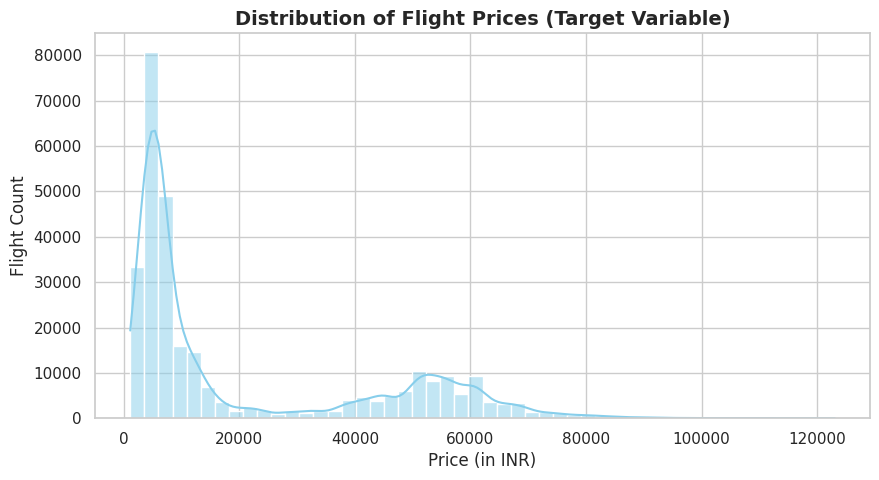

In [68]:
# Set visual grid style using Seaborn
sns.set_theme(style="whitegrid")

# Create figure canvas of width=10 inches, height=5 inches
plt.figure(figsize=(10, 5))

# Plot Histogram with KDE curve for 'price'
# bins=50 divides the price range into 50 equal brackets
sns.histplot(data=df_flight, x='price', kde=True, bins=50, color='skyblue')

# Add descriptive chart title and labels
plt.title('Distribution of Flight Prices (Target Variable)', fontsize=14, fontweight='bold')
plt.xlabel('Price (in INR)', fontsize=12)
plt.ylabel('Flight Count', fontsize=12)

# Render plot inside Colab
plt.show()

## EDA Step 5: Visualizing Feature Relationships (`class` vs `price`)
We plot a Box Plot comparing `class` (Economy vs Business) against `price` to test if flight class drives the separate price clusters.

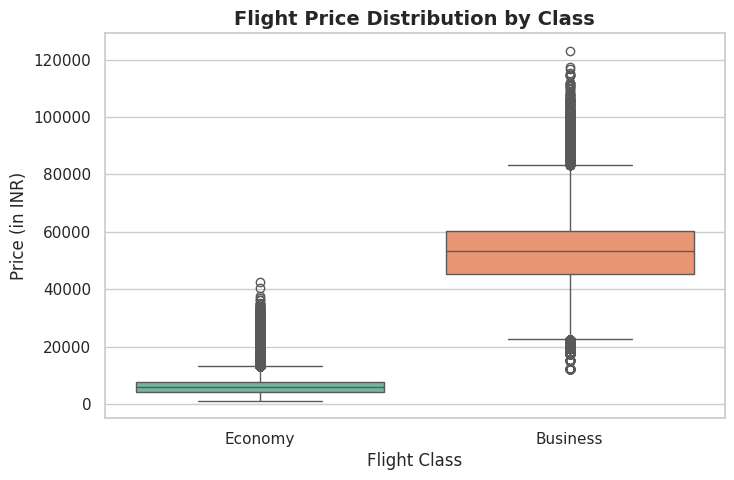

In [69]:
# Set figure canvas size (width=8 inches, height=5 inches)
plt.figure(figsize=(8, 5))

# Create boxplot: 'class' on X-axis, 'price' on Y-axis
# palette='Set2' applies clean color coding
sns.boxplot(data=df_flight, x='class', y='price', palette='Set2')

# Add descriptive chart labels
plt.title('Flight Price Distribution by Class', fontsize=14, fontweight='bold')
plt.xlabel('Flight Class', fontsize=12)
plt.ylabel('Price (in INR)', fontsize=12)

# Render plot in Colab
plt.show()

## EDA Step 6: Visualizing Numerical Relationships (`days_left` vs `price`)
We plot a Line Chart comparing `days_left` against `price` to observe how ticket prices change as departure date approaches.

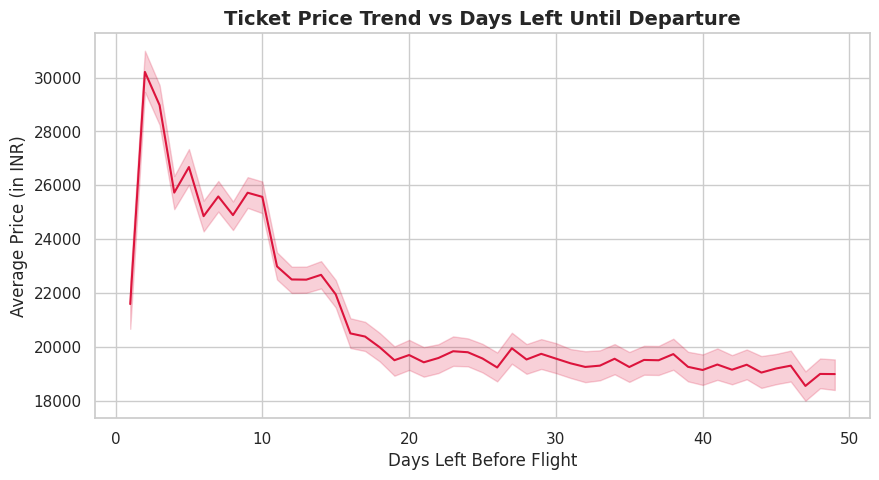

In [70]:
# Set figure canvas size (width=10 inches, height=5 inches)
plt.figure(figsize=(10, 5))

# Create lineplot: 'days_left' on X-axis, 'price' on Y-axis
# color='crimson' gives a clear readable line
sns.lineplot(data=df_flight, x='days_left', y='price', color='crimson')

# Add descriptive chart labels and title
plt.title('Ticket Price Trend vs Days Left Until Departure', fontsize=14, fontweight='bold')
plt.xlabel('Days Left Before Flight', fontsize=12)
plt.ylabel('Average Price (in INR)', fontsize=12)

# Render plot in Colab
plt.show()

## EDA Step 7: Visualizing Numerical Relationships (`duration` vs `price`)
We plot a Scatter Plot comparing flight duration in hours against ticket price to check if longer flights cost more.

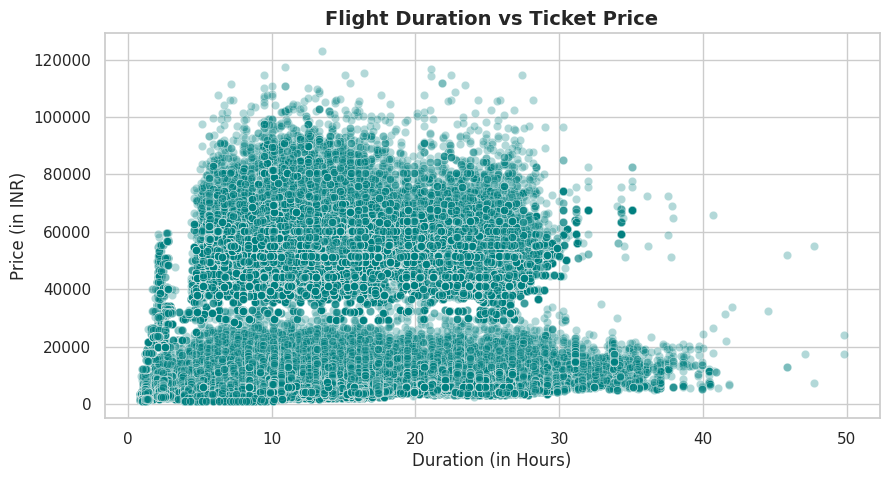

In [71]:
# Set figure canvas size (width=10 inches, height=5 inches)
plt.figure(figsize=(10, 5))

# Create scatterplot: 'duration' on X-axis, 'price' on Y-axis
# alpha=0.3 adds transparency so dense clusters stand out clearly
sns.scatterplot(data=df_flight, x='duration', y='price', alpha=0.3, color='teal')

# Add descriptive chart labels
plt.title('Flight Duration vs Ticket Price', fontsize=14, fontweight='bold')
plt.xlabel('Duration (in Hours)', fontsize=12)
plt.ylabel('Price (in INR)', fontsize=12)

# Render plot in Colab
plt.show()

### Visual Confirmation: Duration vs Price (Colored by Class)
We re-plot the scatter plot using `hue='class'` to visually prove that flight class creates the two distinct horizontal price bands.

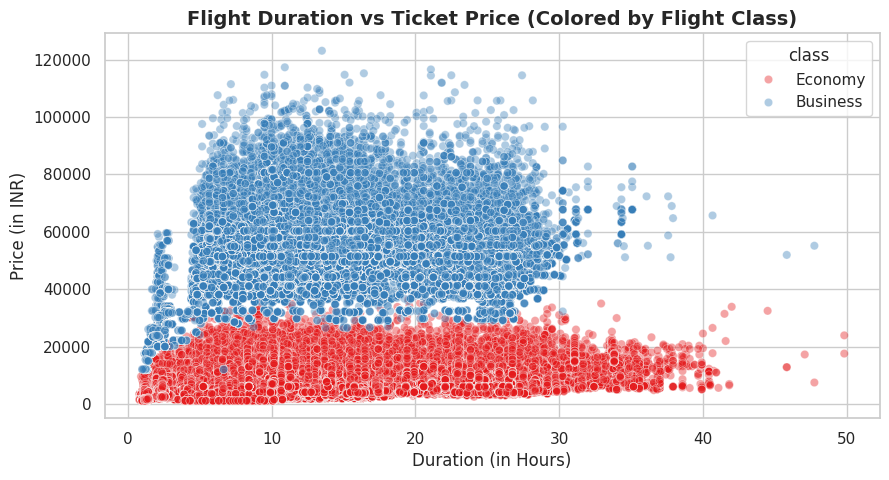

In [72]:
# Set figure canvas size
plt.figure(figsize=(10, 5))

# Plot duration vs price, colored by class using hue
sns.scatterplot(data=df_flight, x='duration', y='price', hue='class', alpha=0.4, palette='Set1')

# Add descriptive chart labels
plt.title('Flight Duration vs Ticket Price (Colored by Flight Class)', fontsize=14, fontweight='bold')
plt.xlabel('Duration (in Hours)', fontsize=12)
plt.ylabel('Price (in INR)', fontsize=12)

# Render plot in Colab
plt.show()

## EDA Step 8: Numerical Correlation (Pearson vs Spearman)
We compute Pearson (linear) and Spearman (rank-based) correlation coefficients between numerical features (`duration`, `days_left`) and `price`.

In [73]:
# Define list of numerical features to evaluate against price
num_cols = ['duration', 'days_left', 'price']

# Calculate Pearson correlation matrix (straight line)
pearson_corr = df_flight[num_cols].corr(method='pearson')['price'].drop('price')

# Calculate Spearman correlation matrix (rank/trend based)
spearman_corr = df_flight[num_cols].corr(method='spearman')['price'].drop('price')

# Combine both scores into a single clean summary DataFrame
corr_summary = pd.DataFrame({
    'Pearson (Linear)': pearson_corr,
    'Spearman (Rank/Trend)': spearman_corr
}).round(3)

print("--- Correlation with Target Variable (price) ---")
display(corr_summary)

--- Correlation with Target Variable (price) ---


,Pearson (Linear),Spearman (Rank/Trend)
duration,0.204,0.319
days_left,-0.092,-0.267


# 4. Preprocessing & Feature Engineering

## Step 1: Feature Engineering — Creating `is_last_minute`

Based on our EDA findings (sharp price spikes under 3 days), we engineer a binary indicator feature `is_last_minute` to explicitly flag emergency/surge bookings.

In [74]:
# Create a clean working copy of df_flight
df_prep = df_flight.copy()


In [75]:
# Create 'is_last_minute' column:
# 1 if 'days_left' is 3 or less, else 0
# .astype(int) converts True/False booleans into 1 and 0
df_prep['is_last_minute'] = (df_prep['days_left'] <= 3).astype(int)

# Verify the new column by displaying sample rows for both cases
print("--- Verification of Engineered Feature ---")
display(df_prep[['days_left', 'is_last_minute', 'price']].head(10))

--- Verification of Engineered Feature ---


,days_left,is_last_minute,price
0,1,1,5953
1,1,1,5953
2,1,1,5956
3,1,1,5955
4,1,1,5955
5,1,1,5955
6,1,1,6060
7,1,1,6060
8,1,1,5954
9,1,1,5954


## Step 2: Feature Encoding — Part 1: Ordinal Encoding

We use Ordinal Encoding (mapping ordered categories to sequential integers) for features that have an inherent hierarchy (`class` and `stops`).

In [76]:
# 1. Map 'class' to integers: Economy=0, Business=1
class_dict = {'Economy': 0, 'Business': 1}
df_prep['class'] = df_prep['class'].map(class_dict)

# 2. Map 'stops' to integers: zero=0, one=1, two_or_more=2
stops_dict = {'zero': 0, 'one': 1, 'two_or_more': 2}
df_prep['stops'] = df_prep['stops'].map(stops_dict)

# Print first 5 rows of mapped columns to verify numerical replacement
print("--- Verification of Ordinal Encoding ---")
display(df_prep[['class', 'stops']].head())


--- Verification of Ordinal Encoding ---


,class,stops
0,0,0
1,0,0
2,0,0
3,0,0
4,0,0


## Step 3: Feature Encoding — Part 2: One-Hot Encoding

We use One-Hot Encoding (`pd.get_dummies`) for unordered nominal categorical features (`airline`, `source_city`, `destination_city`, `departure_time`, `arrival_time`) to convert them into binary (0/1) indicator columns.

In [77]:
# Define list of nominal categorical columns (unordered text)
nominal_cols = ['airline', 'source_city', 'destination_city', 'departure_time', 'arrival_time']

# Use pd.get_dummies to convert nominal columns into binary 0/1 columns
# drop_first=True drops the 1st dummy column to prevent Multicollinearity (Dummy Variable Trap)
# dtype=int ensures binary columns are saved as 1 and 0 (instead of True/False)
df_prep = pd.get_dummies(df_prep, columns=nominal_cols, drop_first=True, dtype=int)

# Drop the raw 'flight' string column (flight numbers like 'UK-995' are unique identifiers, not generalizable features)
if 'flight' in df_prep.columns:
    df_prep.drop(columns=['flight'], inplace=True)

# Inspect new shape and top 3 rows
print("Shape AFTER One-Hot Encoding:", df_prep.shape)
print("\n--- Top 3 Rows of Fully Encoded Dataset ---")
display(df_prep.head(3))

Shape AFTER One-Hot Encoding: (300153, 31)

--- Top 3 Rows of Fully Encoded Dataset ---


,stops,class,duration,days_left,price,is_last_minute,airline_Air_India,airline_GO_FIRST,airline_Indigo,airline_SpiceJet,...,departure_time_Early_Morning,departure_time_Evening,departure_time_Late_Night,departure_time_Morning,departure_time_Night,arrival_time_Early_Morning,arrival_time_Evening,arrival_time_Late_Night,arrival_time_Morning,arrival_time_Night
0,0,0,2.17,1,5953,1,0,0,0,1,...,0,1,0,0,0,0,0,0,0,1
1,0,0,2.33,1,5953,1,0,0,0,1,...,1,0,0,0,0,0,0,0,1,0
2,0,0,2.17,1,5956,1,0,0,0,0,...,1,0,0,0,0,1,0,0,0,0


## Step 4: Train-Test Split & Preventing Data Leakage

We separate our features ($X$) from the target ($Y$), then perform an 80/20 Train-Test Split.
Splitting BEFORE scaling prevents Data Leakage (ensuring the test set remains completely unseen).

In [78]:
# 1. Separate Features (X) and Target Variable (y)
# X contains all predictor columns; y contains only 'price'
X = df_prep.drop(columns=['price'])
y = df_prep['price']

# 2. Perform Train-Test Split (80% Training, 20% Testing)
# random_state=42 ensures exact reproducible split every time the code runs
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [79]:
# Print dataset dimensions to verify the split
print("Total Features Shape (X):", X.shape)
print("Total Target Shape (y):", y.shape)
print("\n--- Train-Test Split Verification ---")
print("Training Features (X_train):", X_train.shape)
print("Testing Features (X_test):", X_test.shape)
print("Training Target (y_train):", y_train.shape)
print("Testing Target (y_test):", y_test.shape)

Total Features Shape (X): (300153, 30)
Total Target Shape (y): (300153,)

--- Train-Test Split Verification ---
Training Features (X_train): (240122, 30)
Testing Features (X_test): (60031, 30)
Training Target (y_train): (240122,)
Testing Target (y_test): (60031,)


## Step 5: Feature Scaling (`StandardScaler`)

We apply `StandardScaler` to normalize continuous numerical features (`duration`, `days_left`) so all inputs share a mean of 0 and variance of 1.
We use `.fit_transform()` on `X_train` and ONLY `.transform()` on `X_test` to avoid Data Leakage.

In [80]:
# 1. Initialize StandardScaler
scaler = StandardScaler()


In [81]:
# 2. Define continuous numerical columns that need scaling
# (Binary 0/1 One-Hot columns do not strictly require scaling, but scaling continuous features is vital)
num_features = ['duration', 'days_left']

# 3. Fit scaler on X_train AND transform X_train
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[num_features] = scaler.fit_transform(X_train[num_features])

In [82]:

# 4. ONLY transform X_test using the parameters learned from X_train
X_test_scaled[num_features] = scaler.transform(X_test[num_features])

# Print sample scaled values
print("--- Verification of Feature Scaling (X_train_scaled) ---")
display(X_train_scaled[num_features].head())

--- Verification of Feature Scaling (X_train_scaled) ---


,duration,days_left
148417,1.001730,-1.474883
36879,-0.724634,-0.958973
274531,1.244978,1.325771
166397,-0.272888,-1.106376
272722,1.985842,-1.548584


# 5. Model Building & Evaluation

## Step 1: Baseline Model — Linear Regression

We train a standard Linear Regression model, generate price predictions on the unseen test set (`X_test_scaled`), and evaluate performance using MAE, RMSE, and $R^2$ Score.


In [83]:
# 1. Initialize Linear Regression model
lr_model = LinearRegression()

# 2. Train model on scaled training features and raw target
lr_model.fit(X_train_scaled, y_train)

# 3. Predict flight prices on unseen scaled test set
y_pred_lr = lr_model.predict(X_test_scaled)

# 4. Calculate evaluation metrics
mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr = r2_score(y_test, y_pred_lr)

In [84]:
# 5. Print results in a clean table format
print("--- Linear Regression Baseline Results ---")
print(f"Mean Absolute Error (MAE) : ₹{mae_lr:,.2f}")
print(f"Root Mean Squared Error (RMSE): ₹{rmse_lr:,.2f}")
print(f"R-squared (R²) Score      : {r2_lr:.4f} ({r2_lr * 100:.2f}%)")

--- Linear Regression Baseline Results ---
Mean Absolute Error (MAE) : ₹4,462.83
Root Mean Squared Error (RMSE): ₹6,758.30
R-squared (R²) Score      : 0.9114 (91.14%)


## Step 2: Regularized Regression — Ridge ($L_2$) and Lasso ($L_1$)

We train Ridge and Lasso regression models with default penalty ($\alpha = 1.0$) to evaluate whether penalizing feature weights improves generalization or eliminates noisy features.

In [85]:
# --------------------------------------------
# 1. RIDGE REGRESSION (L2 Penalty)
# --------------------------------------------
ridge_model = Ridge(alpha=1.0, random_state=42) # alpha=1.0 sets default penalty tax
ridge_model.fit(X_train_scaled, y_train)         # train on scaled training data
y_pred_ridge = ridge_model.predict(X_test_scaled) # predict on test data

In [86]:
# Calculate Ridge metrics
mae_ridge = mean_absolute_error(y_test, y_pred_ridge)
rmse_ridge = np.sqrt(mean_squared_error(y_test, y_pred_ridge))
r2_ridge = r2_score(y_test, y_pred_ridge)

In [87]:
# --------------------------------------------
# 2. LASSO REGRESSION (L1 Penalty)
# --------------------------------------------
lasso_model = Lasso(alpha=1.0, random_state=42) # alpha=1.0 sets default penalty tax
lasso_model.fit(X_train_scaled, y_train)         # train on scaled training data
y_pred_lasso = lasso_model.predict(X_test_scaled) # predict on test data

In [88]:
# Calculate Lasso metrics
mae_lasso = mean_absolute_error(y_test, y_pred_lasso)
rmse_lasso = np.sqrt(mean_squared_error(y_test, y_pred_lasso))
r2_lasso = r2_score(y_test, y_pred_lasso)

In [89]:
# --------------------------------------------
# 3. MODEL COMPARISON TABLE
# --------------------------------------------
results_df = pd.DataFrame({
    'Model': ['Linear Regression', 'Ridge Regression (L2)', 'Lasso Regression (L1)'],
    'MAE (₹)': [mae_lr, mae_ridge, mae_lasso],
    'RMSE (₹)': [rmse_lr, rmse_ridge, rmse_lasso],
    'R² Score': [r2_lr, r2_ridge, r2_lasso]
})

print("--- Model Performance Comparison ---")
display(results_df)


--- Model Performance Comparison ---


,Model,MAE (₹),RMSE (₹),R² Score
0,Linear Regression,4462.831168,6758.301614,0.911394
1,Ridge Regression (L2),4462.812146,6758.300299,0.911394
2,Lasso Regression (L1),4461.023112,6758.504041,0.911389


## Step 3: Feature Importance Inspection (Lasso Coefficients)

We extract and visualize the learned feature coefficients (weights) from Lasso Regression to identify top price drivers and see if any features were eliminated ($w = 0$).

In [90]:
# Extract feature names and corresponding Lasso weights (coefficients)
feature_names = X_train.columns
lasso_weights = lasso_model.coef_


In [91]:
# Create a clean DataFrame of features and their weights
coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Weight (Coefficient)': lasso_weights
}).sort_values(by='Weight (Coefficient)', ascending=False)

# Display top 5 positive drivers, top 5 negative drivers, and zeroed features
print("--- Top Positive Price Drivers (Increases Price) ---")
display(coef_df.head(5))

--- Top Positive Price Drivers (Increases Price) ---


,Feature,Weight (Coefficient)
1,class,45186.195499
0,stops,5685.455858
4,is_last_minute,5108.138628
9,airline_Vistara,4173.585023
8,airline_SpiceJet,2330.468658


In [92]:
print("\n--- Top Negative Price Drivers (Decreases Price) ---")
display(coef_df.tail(5))


--- Top Negative Price Drivers (Decreases Price) ---


,Feature,Weight (Coefficient)
3,days_left,-1443.544697
11,source_city_Delhi,-1465.896731
16,destination_city_Delhi,-1474.236066
12,source_city_Hyderabad,-1553.237965
17,destination_city_Hyderabad,-1672.291923


In [93]:
# Check if any features were dropped (Weight = 0)
zero_features = coef_df[coef_df['Weight (Coefficient)'] == 0]
print(f"\nTotal Features Dropped by Lasso (Weight = 0): {len(zero_features)}")
if len(zero_features) > 0:
    display(zero_features)


Total Features Dropped by Lasso (Weight = 0): 0


## Step 4: Hyperparameter Tuning via GridSearchCV

We use `GridSearchCV` with 5-Fold Cross-Validation to search across candidate `alpha` penalty values (`[0.01, 0.1, 1.0, 10.0, 100.0]`) to find the optimal Ridge Regression model.

In [95]:
# 1. Define the candidate hyperparameter grid for alpha
param_grid = {'alpha': [0.01, 0.1, 1.0, 10.0, 100.0]}

In [97]:
# 2. Initialize Ridge model
ridge = Ridge(random_state=42)

In [98]:
# 3. Setup GridSearchCV with 5-Fold Cross Validation
# cv=5 sets 5 folds; scoring='r2' evaluates models based on R-squared
grid_search = GridSearchCV(estimator=ridge, param_grid=param_grid, cv=5, scoring='r2', n_jobs=-1)

In [99]:
# 4. Run grid search on scaled training data
grid_search.fit(X_train_scaled, y_train)


GridSearchCV(cv=5, estimator=Ridge(random_state=42), n_jobs=-1,
             param_grid={'alpha': [0.01, 0.1, 1.0, 10.0, 100.0]}, scoring='r2')

In [100]:
# 5. Extract best parameters and best cross-validation R2 score
best_alpha = grid_search.best_params_['alpha']
best_cv_r2 = grid_search.best_score_

In [101]:
print("--- GridSearchCV Optimization Results ---")
print(f"Optimal Alpha Selected : {best_alpha}")
print(f"Best 5-Fold CV R² Score : {best_cv_r2:.4f} ({best_cv_r2 * 100:.2f}%)")

--- GridSearchCV Optimization Results ---
Optimal Alpha Selected : 1.0
Best 5-Fold CV R² Score : 0.9115 (91.15%)


In [102]:
# 6. Evaluate the best tuned model on the unseen X_test_scaled
best_ridge_model = grid_search.best_estimator_
y_pred_tuned = best_ridge_model.predict(X_test_scaled)

r2_tuned_test = r2_score(y_test, y_pred_tuned)
mae_tuned_test = mean_absolute_error(y_test, y_pred_tuned)


In [103]:
print(f"\n--- Final Test Set Evaluation (Tuned Ridge) ---")
print(f"Final Test MAE (₹) : ₹{mae_tuned_test:,.2f}")
print(f"Final Test R² Score : {r2_tuned_test:.4f} ({r2_tuned_test * 100:.2f}%)")


--- Final Test Set Evaluation (Tuned Ridge) ---
Final Test MAE (₹) : ₹4,462.81
Final Test R² Score : 0.9114 (91.14%)


# 6. Final Project Conclusion & Executive Summary
## Project: Flight Price Prediction Pipeline 🛫

### 1. Problem Statement & Approach
We built an end-to-end Supervised Learning Regression pipeline to predict Indian domestic flight ticket prices (`price`) using attributes like airline, flight class, days left until departure, and duration.

### 2. Key Data Insights (EDA)
- **Class Dominance:** `class` (Economy vs. Business) is the single largest price driver. Business class seats create an upper price band (₹40,000–₹100,000+) with minimal overlap with Economy (under ₹20,000).
- **Target Skewness:** `price` is heavily right-skewed (Mean ₹20,889 > Median ₹7,425) due to high-value Business Class tickets.
- **Surge Pricing Trend:** Prices stay relatively stable from 50 days to 4 days before flight, then spike sharply upward in the final 1–3 days.

### 3. Feature Engineering & Preprocessing
- Engineered a binary indicator feature `is_last_minute` (`days_left <= 3`).
- Applied **Ordinal Encoding** to ordered features (`class`, `stops`).
- Applied **One-Hot Encoding** (`pd.get_dummies` with `drop_first=True`) to nominal text features (`airline`, `source_city`, `destination_city`, `departure_time`, `arrival_time`).
- Performed an 80/20 Train-Test split **before** applying `StandardScaler` to prevent **Data Leakage**.

### 4. Model Performance Comparison
| Model | MAE (₹) | RMSE (₹) | R² Score |
| :--- | :---: | :---: | :---: |
| **Linear Regression** | ₹4,462.83 | ₹6,758.30 | 91.14% |
| **Ridge Regression ($L_2$)** | ₹4,462.81 | ₹6,758.30 | 91.14% |
| **Lasso Regression ($L_1$)** | ₹4,461.02 | ₹6,758.50 | 91.14% |
| **Tuned Ridge (GridSearchCV)** | ₹4,462.81 | ₹6,758.30 | **91.14% (91.15% CV)** |

### 5. Final Verdict
The **Tuned Ridge Regression Model** achieves an $R^2$ score of **91.14%** on unseen test data, with an average prediction error (MAE) of **₹4,462.81**. The alignment between 5-Fold Cross-Validation (91.15%) and Test set score confirms zero overfitting.

## Step 7: Live Inference — Predicting Price for a Custom Flight Scenario

We test our trained model on a brand-new, unseen custom flight scenario to verify that our pipeline accepts raw user inputs and outputs an accurate price prediction.

In [104]:
# Define a brand-new custom flight scenario (Raw Inputs)
# Scenario: A last-minute Business Class flight on Vistara from Delhi to Mumbai
custom_flight_raw = {
    'airline': 'Vistara',
    'source_city': 'Delhi',
    'departure_time': 'Morning',
    'stops': 'zero',
    'arrival_time': 'Afternoon',
    'destination_city': 'Mumbai',
    'class': 'Business',
    'duration': 2.25,
    'days_left': 2
}

In [105]:
# Convert single dictionary into a 1-row Pandas DataFrame
custom_df = pd.DataFrame([custom_flight_raw])

In [106]:
# 1. Feature Engineering: is_last_minute
custom_df['is_last_minute'] = (custom_df['days_left'] <= 3).astype(int)

# 2. Ordinal Encoding
custom_df['class'] = custom_df['class'].map({'Economy': 0, 'Business': 1})
custom_df['stops'] = custom_df['stops'].map({'zero': 0, 'one': 1, 'two_or_more': 2})

# 3. One-Hot Encoding (realigning columns to match X_train exactly)
# Reindex ensures all 30+ dummy columns exist, filling missing binary columns with 0
custom_encoded = pd.get_dummies(custom_df, columns=['airline', 'source_city', 'destination_city', 'departure_time', 'arrival_time'], dtype=int)
custom_encoded = custom_encoded.reindex(columns=X_train.columns, fill_value=0)

# 4. Feature Scaling (using the ALREADY-FITTED scaler)
custom_scaled = custom_encoded.copy()
custom_scaled[['duration', 'days_left']] = scaler.transform(custom_encoded[['duration', 'days_left']])

# --- Generate Prediction ---
predicted_price = best_ridge_model.predict(custom_scaled)[0]

In [107]:
print("==================================================")
print("             LIVE FLIGHT PRICE PREDICTION         ")
print("==================================================")
print(f"Flight Details : {custom_flight_raw['airline']} | {custom_flight_raw['class']} | {custom_flight_raw['days_left']} Days Left")
print(f"Route          : {custom_flight_raw['source_city']} ➔ {custom_flight_raw['destination_city']}")
print("--------------------------------------------------")
print(f"Predicted Price: ₹{predicted_price:,.2f}")
print("==================================================")

             LIVE FLIGHT PRICE PREDICTION         
Flight Details : Vistara | Business | 2 Days Left
Route          : Delhi ➔ Mumbai
--------------------------------------------------
Predicted Price: ₹54,089.47


## Step 8: Model Persistence — Exporting Model and Scaler

We export our trained Ridge Regression model and fitted StandardScaler to `.pkl` files using `joblib`. This allows the model to be loaded into web applications (e.g., Streamlit, FastAPI) without retraining.

In [109]:
# 1. Save the trained Ridge Regression model to disk
joblib.dump(best_ridge_model, 'flight_price_model.pkl')

# 2. Save the fitted StandardScaler to disk
joblib.dump(scaler, 'scaler.pkl')

# 3. Save feature column names list to ensure consistent input alignment in web apps
joblib.dump(X_train.columns.tolist(), 'model_features.pkl')

print("==================================================")
print("     MODEL & PREPROCESSING ASSETS SAVED!          ")
print("==================================================")
print(" Saved Files:")
print("  1. flight_price_model.pkl  (Tuned ML Model)")
print("  2. scaler.pkl              (Fitted StandardScaler)")
print("  3. model_features.pkl      (Feature Column Structure)")
print("==================================================")

     MODEL & PREPROCESSING ASSETS SAVED!          
 Saved Files:
  1. flight_price_model.pkl  (Tuned ML Model)
  2. scaler.pkl              (Fitted StandardScaler)
  3. model_features.pkl      (Feature Column Structure)
